Data Quality Assessment

In [27]:
import sys
!{sys.executable} -m pip install  scipy

  Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl.metadata (60 kB)
Using cached scipy-1.17.1-cp314-cp314-win_amd64.whl (37.3 MB)


In [36]:
import pandas as pd

df = pd.read_csv("data/data.txt", sep="|", engine="python")
# percentage of missing values
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'MissingCount': missing,
    'MissingPercent': missing_percent
}).sort_values(by='MissingPercent', ascending=False)

missing_df

df.drop(columns=[
    'NumberOfVehiclesInFleet',
    'CrossBorder'
], inplace=True)

Extremely high missing (>60–100%)
NumberOfVehiclesInFleet → 100%
CrossBorder → ~100%
CustomValueEstimate → ~78%
Rebuilt, Converted, WrittenOff → ~64%
Columns with near-complete missingness (>99%) were removed as they provide no analytical value

Data Summarization

In [5]:
df.dtypes

UnderwrittenCoverID           int64
PolicyID                      int64
TransactionMonth                str
IsVATRegistered                bool
Citizenship                     str
LegalType                       str
Title                           str
Language                        str
Bank                            str
AccountType                     str
MaritalStatus                   str
Gender                          str
Country                         str
Province                        str
PostalCode                    int64
MainCrestaZone                  str
SubCrestaZone                   str
ItemType                        str
mmcode                      float64
VehicleType                     str
RegistrationYear              int64
make                            str
Model                           str
Cylinders                   float64
cubiccapacity               float64
kilowatts                   float64
bodytype                        str
NumberOfDoors               

In [38]:
df['VehicleIntroDate'] = pd.to_datetime(
    df['VehicleIntroDate'],
    format='%m/%Y',
    errors='coerce'
)

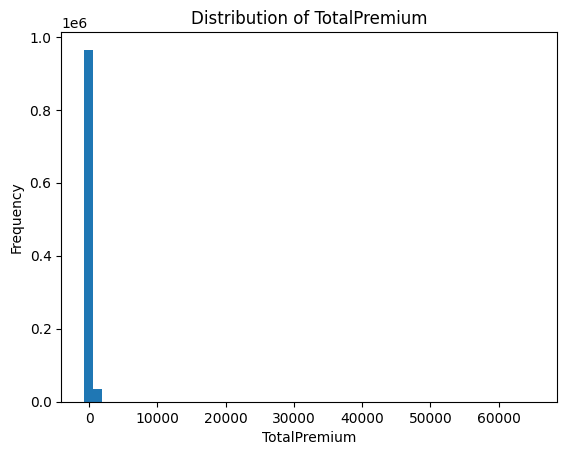

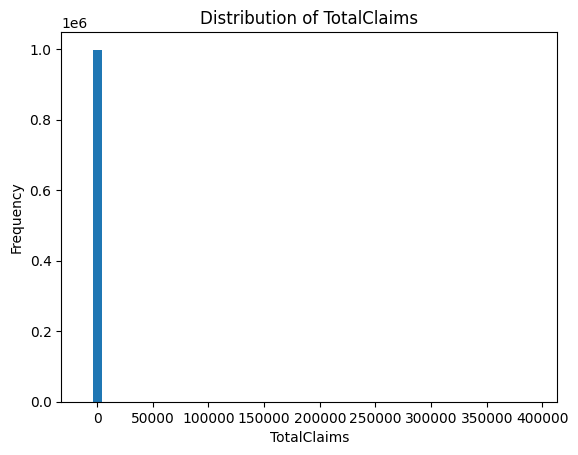

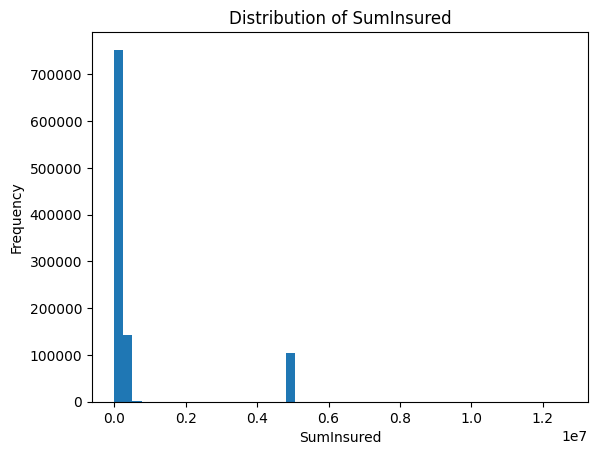

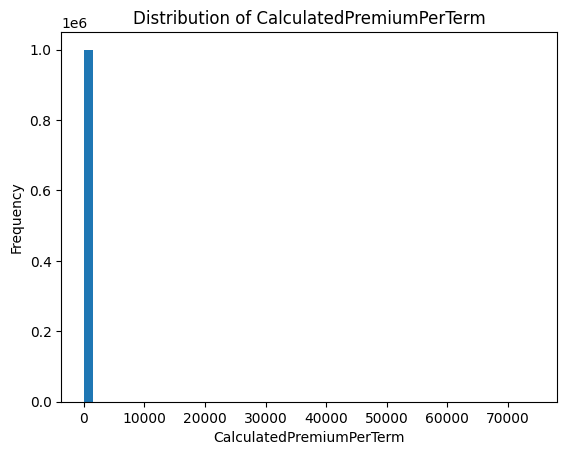

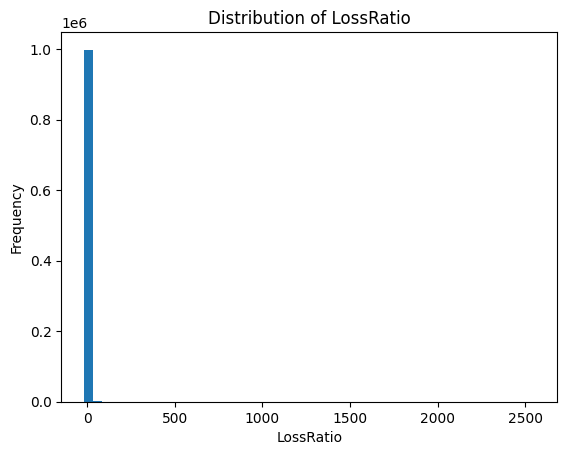

In [39]:
import matplotlib.pyplot as plt
import numpy as np

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df['LossRatio'] = np.where(
    df['TotalPremium'] == 0,
    0,
    df['TotalClaims'] / df['TotalPremium']
)
df['LossRatio'] = df['LossRatio'].fillna(0)
num_cols = ['TotalPremium', 'TotalClaims', 'SumInsured', 'CalculatedPremiumPerTerm', 'LossRatio']

for col in num_cols:
    clean_data = df[col].replace([np.inf, -np.inf], np.nan).dropna()

    plt.figure()
    plt.hist(clean_data, bins=50)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

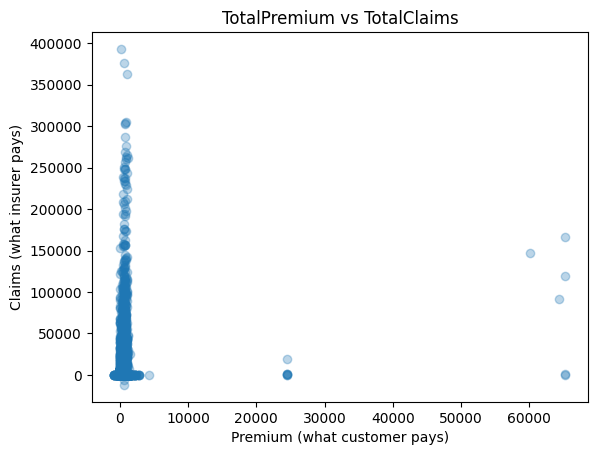

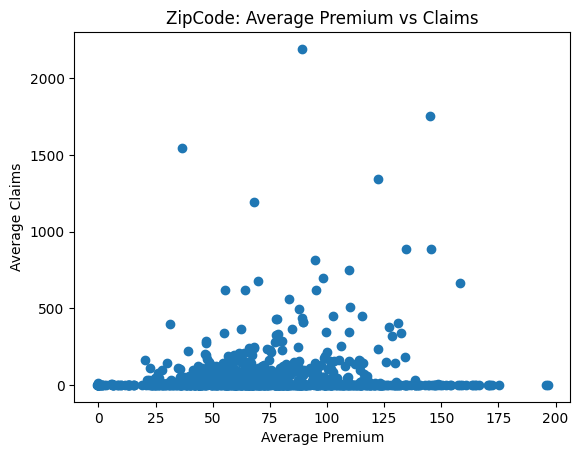

In [40]:
import matplotlib.pyplot as plt

plt.scatter(df['TotalPremium'], df['TotalClaims'], alpha=0.3)
plt.title("TotalPremium vs TotalClaims")
plt.xlabel("Premium (what customer pays)")
plt.ylabel("Claims (what insurer pays)")
plt.show()



zip_data = df.groupby('PostalCode')[['TotalPremium', 'TotalClaims']].mean()
zip_data.head()
plt.scatter(zip_data['TotalPremium'], zip_data['TotalClaims'])
plt.title("ZipCode: Average Premium vs Claims")
plt.xlabel("Average Premium")
plt.ylabel("Average Claims")
plt.show()

In [11]:
df[['TotalPremium', 'TotalClaims']].corr()

,TotalPremium,TotalClaims
TotalPremium,1.000000,0.121588
TotalClaims,0.121588,1.000000


 The correlation between TotalPremium and TotalClaims was found to be 0.12, indicating a very weak positive relationship. This suggests that premium amounts are not strongly driven by historical claims alone. Instead, pricing appears to be influenced by multiple underwriting factors such as vehicle value, risk classification, and policy characteristics.

The weak correlation is expected in insurance datasets, where claims are infrequent and highly variable, while premiums are set using broader risk assessment models.

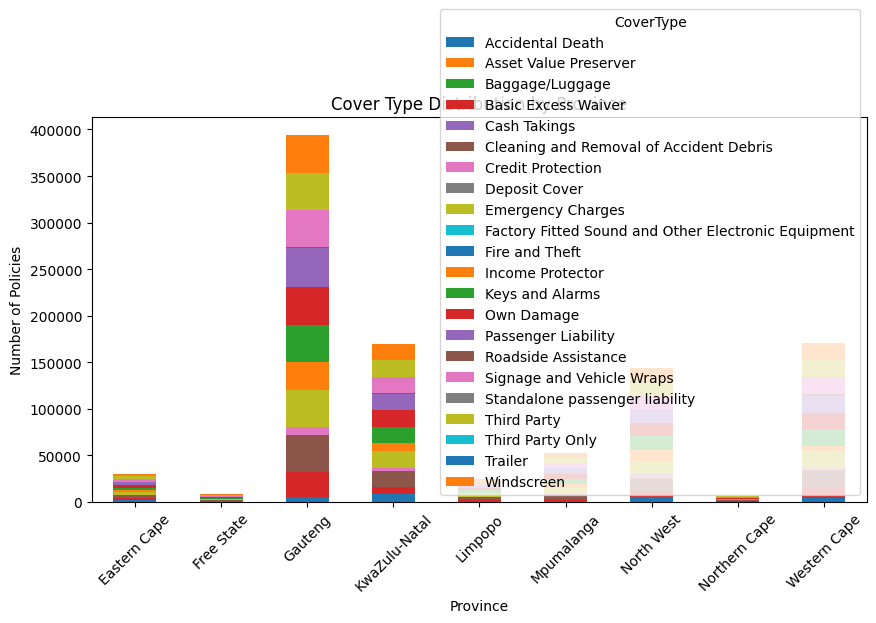

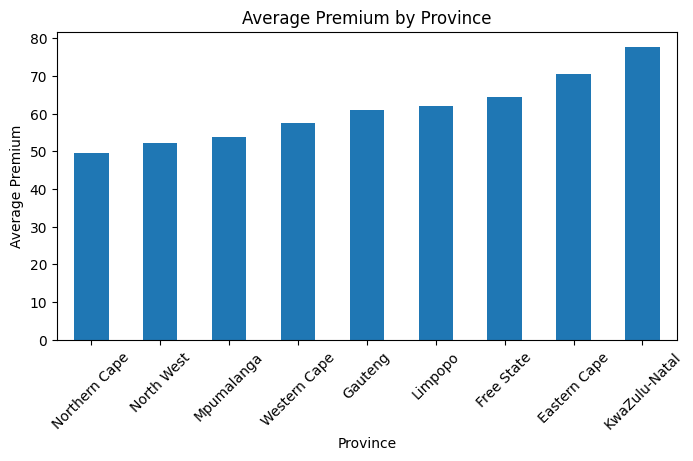

In [41]:
import matplotlib.pyplot as plt

province_cover = df.groupby(['Province', 'CoverType']).size().unstack()

province_cover.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title("Cover Type Distribution by Province")
plt.ylabel("Number of Policies")
plt.xticks(rotation=45)
plt.show()
province_premium = df.groupby('Province')['TotalPremium'].mean().sort_values()

province_premium.plot(kind='bar', figsize=(8,4))

plt.title("Average Premium by Province")
plt.ylabel("Average Premium")
plt.xticks(rotation=45)
plt.show()

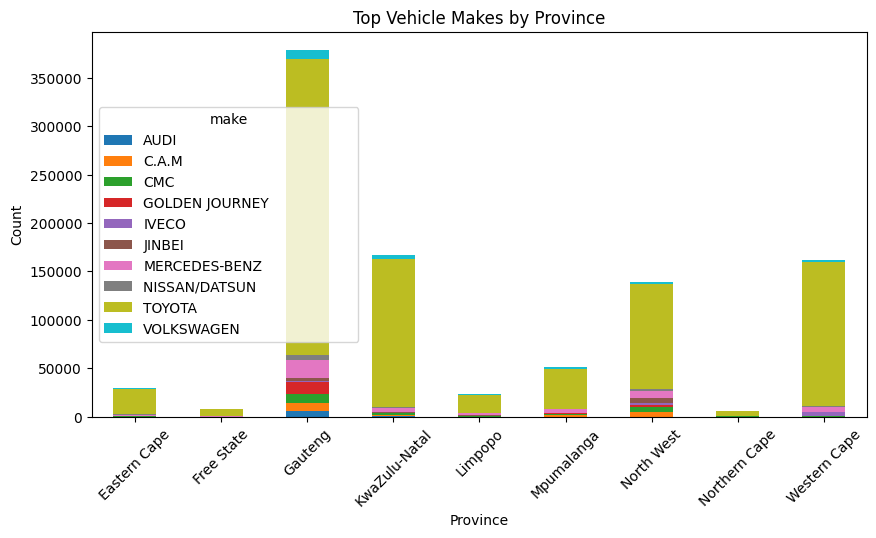

In [42]:
top_makes = df['make'].value_counts().head(10).index
filtered = df[df['make'].isin(top_makes)]

make_province = filtered.groupby(['Province', 'make']).size().unstack()

make_province.plot(kind='bar', stacked=True, figsize=(10,5))

plt.title("Top Vehicle Makes by Province")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

Answer for guiding questions

1. First: Overall Loss Ratio (Portfolio level)

In [43]:
import numpy as np

df['LossRatio'] = df['TotalClaims'] / df['TotalPremium']
df['LossRatio'] = df['LossRatio'].replace([np.inf, -np.inf], np.nan).fillna(0)

overall_loss_ratio = df['LossRatio'].mean()
overall_loss_ratio

np.float64(0.21636986096323912)

since it is < 1 it is profitable portfolio

2. Loss Ratio by Province

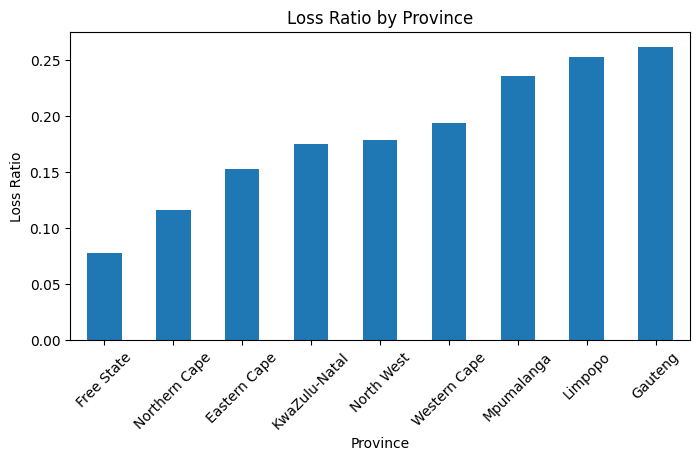

In [44]:
province_lr = df.groupby('Province')['LossRatio'].mean().sort_values()

province_lr.plot(kind='bar', figsize=(8,4))
plt.title("Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.xticks(rotation=45)
plt.show()

Gauteng have high loss ratio


3. Loss Ratio by Vehicle Type

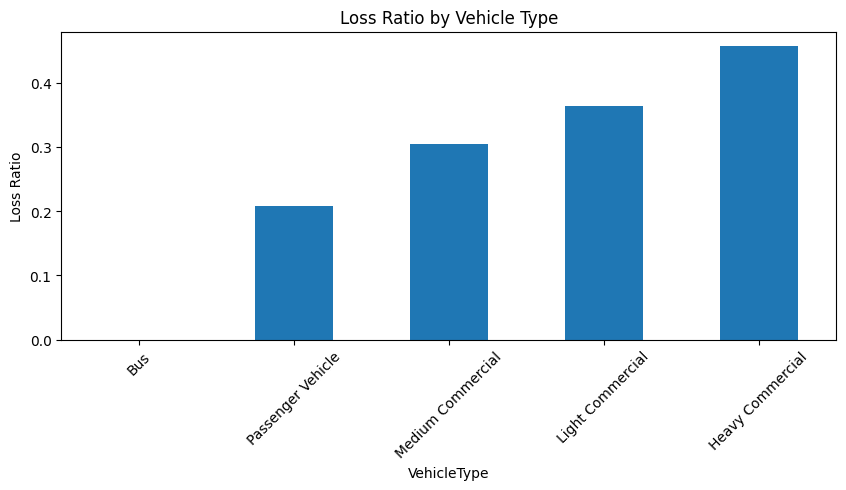

In [45]:
vehicle_lr = df.groupby('VehicleType')['LossRatio'].mean().sort_values()

vehicle_lr.plot(kind='bar', figsize=(10,4))
plt.title("Loss Ratio by Vehicle Type")
plt.ylabel("Loss Ratio")
plt.xticks(rotation=45)
plt.show()

Heavy commericals have high loss ratio

End of first Question

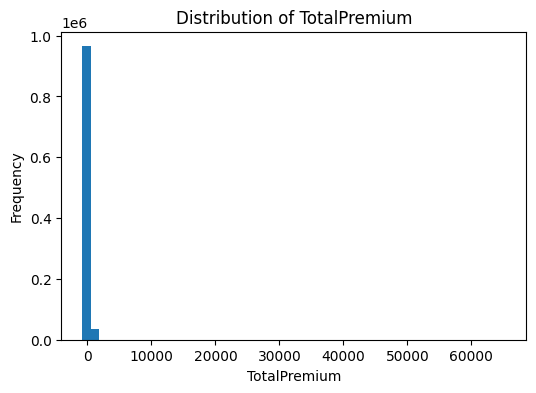

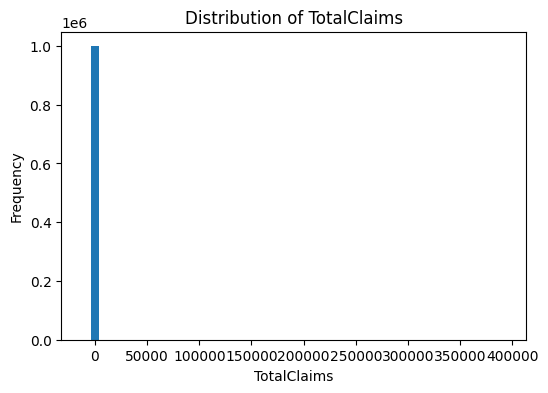

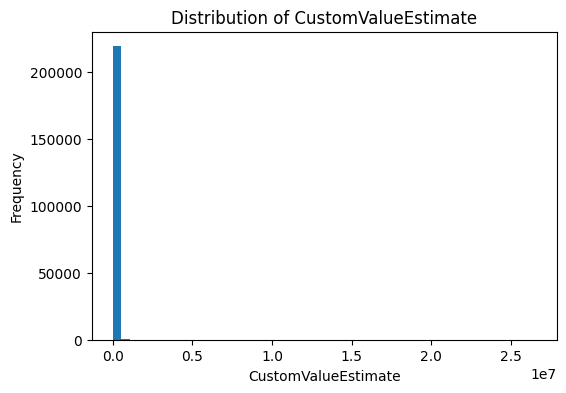

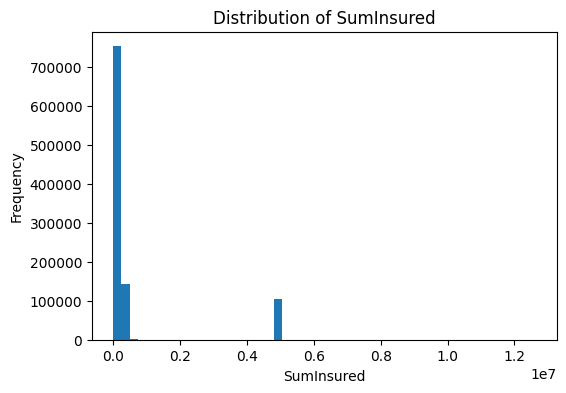

In [46]:
import matplotlib.pyplot as plt

financial_cols = ['TotalPremium', 'TotalClaims', 'CustomValueEstimate', 'SumInsured']

for col in financial_cols:
    plt.figure(figsize=(6,4))
    plt.hist(df[col].dropna(), bins=50)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

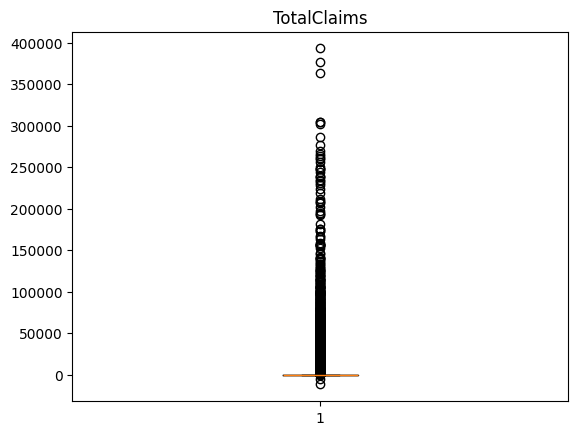

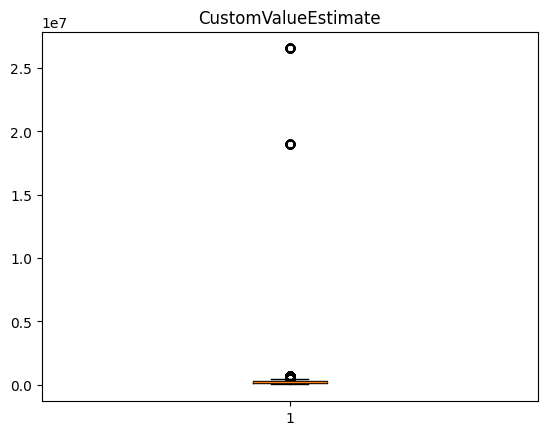

In [47]:
for col in ['TotalClaims', 'CustomValueEstimate']:
    plt.boxplot(df[col].dropna())
    plt.title(col)
    plt.show()

yes there are  outliers in TotalClaims or CustomValueEstimate that could skew analysis?

End of question number 2

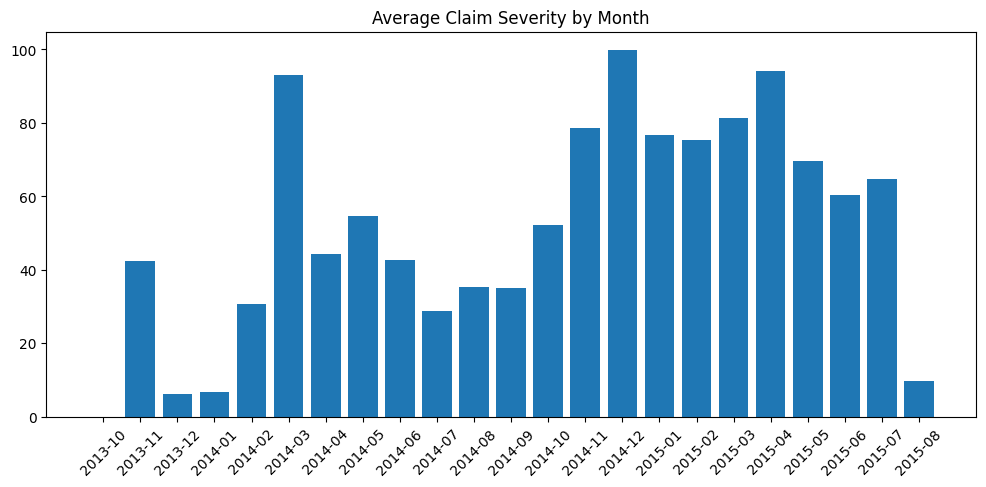

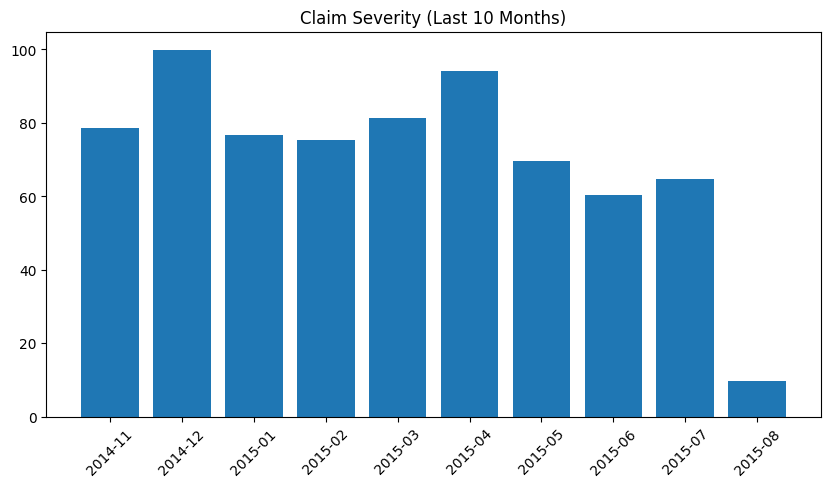

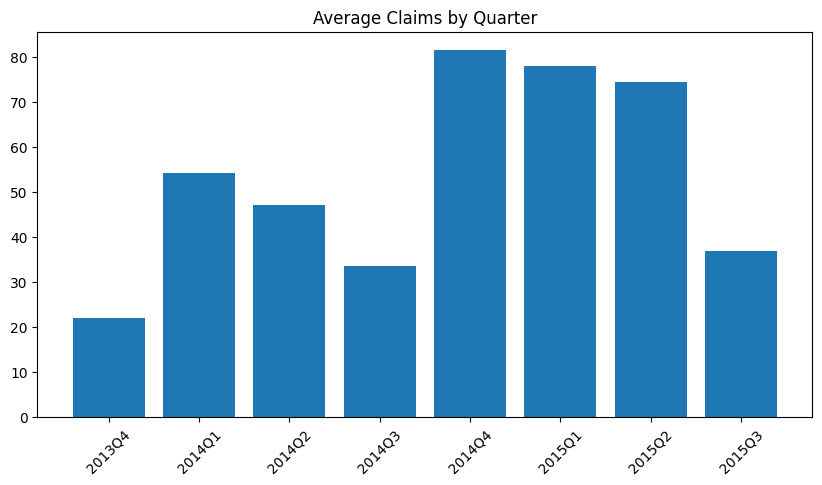

In [48]:
import matplotlib.pyplot as plt

monthly = df.copy()
monthly['TransactionMonth'] = pd.to_datetime(monthly['TransactionMonth'])

monthly_summary = monthly.groupby(monthly['TransactionMonth'].dt.to_period('M')).agg({
    'TotalClaims': 'mean'
}).reset_index()

monthly_summary['TransactionMonth'] = monthly_summary['TransactionMonth'].astype(str)

plt.figure(figsize=(12,5))
plt.bar(monthly_summary['TransactionMonth'], monthly_summary['TotalClaims'])
plt.title("Average Claim Severity by Month")
plt.xticks(rotation=45)
plt.show()

last_months = monthly_summary.tail(10)

plt.figure(figsize=(10,5))
plt.bar(last_months['TransactionMonth'], last_months['TotalClaims'])
plt.title("Claim Severity (Last 10 Months)")
plt.xticks(rotation=45)
plt.show()

df['TransactionMonth'] = pd.to_datetime(df['TransactionMonth'])

quarterly = df.groupby(df['TransactionMonth'].dt.to_period('Q')).agg({
    'TotalClaims': 'mean',
    'TotalPremium': 'mean'
}).reset_index()

quarterly['TransactionMonth'] = quarterly['TransactionMonth'].astype(str)

plt.figure(figsize=(10,5))
plt.bar(quarterly['TransactionMonth'], quarterly['TotalClaims'])
plt.title("Average Claims by Quarter")
plt.xticks(rotation=45)
plt.show()

The results show no clear long-term upward or downward trend in claim severity, with fluctuations appearing randomly across periods. 

End of question 3

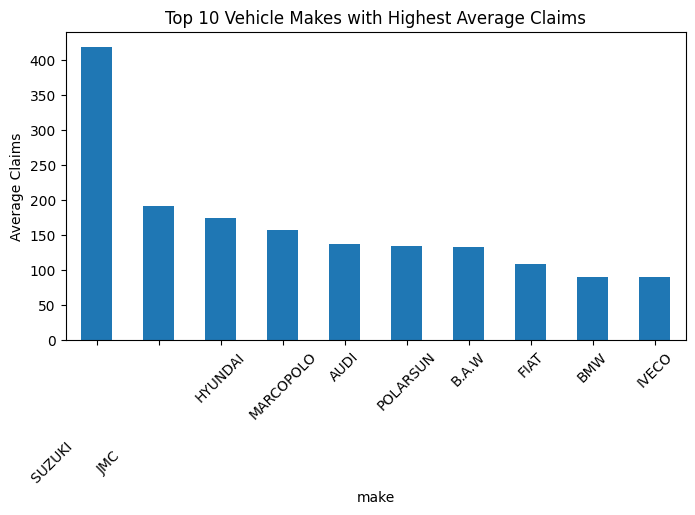

make
HINO                                   0.0
JINBEI                                 0.0
LEXUS                                  0.0
PROTON                                 0.0
PEUGEOT                                0.0
OPEL                                   0.0
RENAULT                                0.0
SCANIA                                 0.0
TATA                                   0.0
VOLVO                                  0.0
Name: TotalClaims, dtype: float64

In [49]:
import pandas as pd
import numpy as np

df['TotalClaims'] = pd.to_numeric(df['TotalClaims'], errors='coerce')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
make_claims = df.groupby('make')['TotalClaims'].mean().sort_values(ascending=False)
make_claims
make_claims.head(10)
make_claims.head(10).plot(kind='bar', figsize=(8,4))
plt.title("Top 10 Vehicle Makes with Highest Average Claims")
plt.ylabel("Average Claims")
plt.xticks(rotation=45)
plt.show()
make_claims.tail(10)


SUZUKI vehicle makes/models are associated with the highest claim amount.
Land cruser makes the lowest claim amount.


 Plot 1: Loss Ratio by Province (Risk Heat by Geography)

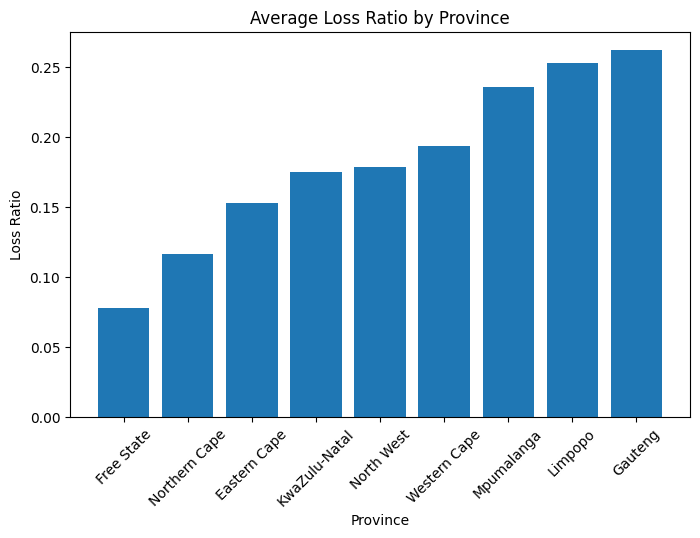

In [50]:
import matplotlib.pyplot as plt

province_lr = df.groupby('Province')['LossRatio'].mean().sort_values()

plt.figure(figsize=(8,5))
plt.bar(province_lr.index, province_lr.values)
plt.title("Average Loss Ratio by Province")
plt.ylabel("Loss Ratio")
plt.xlabel("Province")
plt.xticks(rotation=45)
plt.show()

Provinces show clear variation in loss ratio, indicating geographic differences in risk exposure. Gauteng exhibit significantly higher loss ratios, suggesting higher claims relative to premiums.

 Plot 2: Top Vehicle Makes by Average Claims (Risk by Brand)

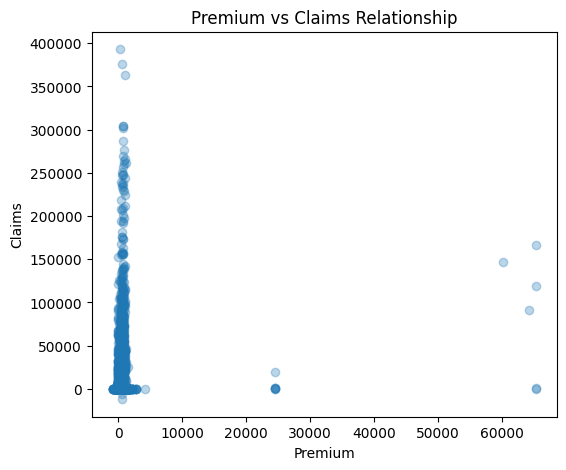

In [51]:
plt.figure(figsize=(6,5))
plt.scatter(df['TotalPremium'], df['TotalClaims'], alpha=0.3)
plt.title("Premium vs Claims Relationship")
plt.xlabel("Premium")
plt.ylabel("Claims")
plt.show()

Plot 3: Loss Ratio by Gender (Customer Risk Behaviors)

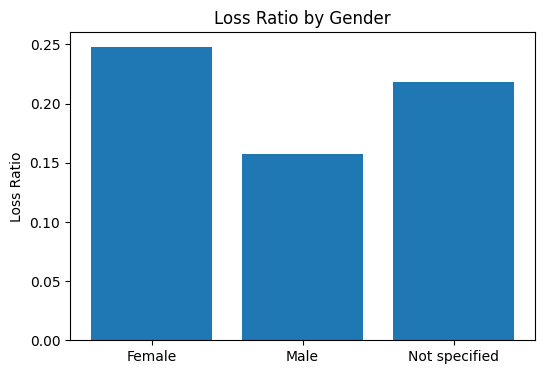

In [52]:
gender_lr = df.groupby('Gender')['LossRatio'].mean()

plt.figure(figsize=(6,4))
plt.bar(gender_lr.index.astype(str), gender_lr.values)
plt.title("Loss Ratio by Gender")
plt.ylabel("Loss Ratio")
plt.show()

Females have higher loss ratio.


In [24]:
df = pd.read_csv("data/data.txt", sep="|")

# simple cleaning
df = df.dropna()

df.to_csv("data/data2.txt", index=False)

C:\Users\cbe\AppData\Local\Temp\ipykernel_16664\1411479435.py:1: DtypeWarning: Columns (0: CapitalOutstanding, 1: CrossBorder) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/data.txt", sep="|")


Two versions of the dataset were created and tracked using DVC. The initial version consisted of the raw dataset, while a second version was generated after applying basic data cleaning operations such as handling missing values.

Each version was tracked using DVC and pushed to local remote storage. This allows reproducibility and the ability to revert to previous data states, ensuring a robust and production-ready data pipeline.

top_zips = df["PostalCode"].value_counts().head(10).index
df_zip = df[df["PostalCode"].isin(top_zips)]

In [53]:
top_zips = df["PostalCode"].value_counts().head(10).index
df_zip = df[df["PostalCode"].isin(top_zips)]

In [54]:
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
# Margin
df["Margin"] = df["TotalPremium"] - df["TotalClaims"]

# Claim Frequency (0 or 1)
df["HasClaim"] = (df["TotalClaims"] > 0).astype(int)


HYPOTHESIS 1: Provinces
Do provinces have different risk?:
KPI
Use Claim Frequency

In [55]:
df["Province"].value_counts().head()
group_A = df[df["Province"] == "Gauteng"]
group_B = df[df["Province"] == "Western Cape"]
freq_A = group_A["HasClaim"].mean()
freq_B = group_B["HasClaim"].mean()

print(freq_A, freq_B)
t_stat, p_val = ttest_ind(group_A["HasClaim"], group_B["HasClaim"], nan_policy="omit")

print("p-value:", p_val)

0.0033564800121869166 0.002166327080259491
p-value: 5.6552929751767926e-14


Claim Frequency (Gauteng): 0.003356
Claim Frequency (Western Cape): 0.002166
p-value: 5.65e-14 (≈ 0.000000000000056)

 Gauteng has higher claim frequency
 p < 0.05 → Reject H₀
 5.65e-14  <  0.05  so we reject the HYPOTHESIS.
 Business Interpretation
 We reject the null hypothesis that there are no differences in risk across provinces. The analysis shows a statistically significant difference in claim frequency between provinces, with Gauteng exhibiting a higher risk level compared to Western Cape.

This indicates that geographic location is a meaningful driver of insurance risk in the portfolio. From a business perspective, this suggests that a one-size-fits-all pricing strategy across provinces is suboptimal. ACIS should consider implementing province-specific pricing adjustments to better align premiums with observed risk levels.

In particular, higher-risk provinces such as Gauteng may require higher premiums or stricter underwriting criteria, while lower-risk provinces could be targeted with competitive pricing to attract new customers without compromising profitability.

In [63]:
top_zips = df["PostalCode"].value_counts().head(5).index
df_zip = df[df["PostalCode"].isin(top_zips)]
zip1 = top_zips[0]
zip2 = top_zips[1]
print(zip1)
print(zip2)

group_A = df_zip[df_zip["PostalCode"] == zip1]
group_B = df_zip[df_zip["PostalCode"] == zip2]
freq_A = group_A["HasClaim"].mean()
freq_B = group_B["HasClaim"].mean()

print(freq_A, freq_B)
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(group_A["HasClaim"], group_B["HasClaim"], nan_policy="omit")

print("p-value:", p_val)


2000
122
0.003640503977587679 0.004270810030302414
p-value: 0.05245287956147355


Claim frequency:

Group A: 0.00364 (0.364%)(postal code 2000)
Group B: 0.00427 (0.427%) (postal code 122)
Group B has slightly higher claim frequency
p < 0.05 → Reject H₀  
p ≥ 0.05 → Fail to reject H₀
My  value:
0.05245 > 0.05
FAIL to reject H₀
Business interpretation

While PostalCode B shows a slightly higher claim frequency than PostalCode A, the difference is not statistically significant (p = 0.052). Therefore, we fail to reject the null hypothesis and conclude that there is no strong evidence of different risk levels between the selected postal codes.
We fail to reject the null hypothesis that there are no differences in risk between postal codes. Although slight differences in claim frequency were observed between the selected postal codes, the results are not statistically significant at the 5% level.

This suggests that there is insufficient evidence to conclude that geographic location at the postal code level is a strong driver of insurance risk in this sample. As a result, postal code alone should not be used as a primary factor for differentiated pricing without further supporting variables.

From a business perspective, this indicates that finer segmentation (such as combining postal code with vehicle type or customer profile) may be more effective than relying solely on geographic segmentation when assessing risk.

In [59]:
top_zips = df["PostalCode"].value_counts().head(5).index
df_zip = df[df["PostalCode"].isin(top_zips)]
df_zip["Margin"] = df_zip["TotalPremium"] - df_zip["TotalClaims"]
print(group_A["Margin"].mean())
print(group_B["Margin"].mean())
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    group_A["Margin"],
    group_B["Margin"],
    nan_policy="omit"
)

print("p-value:", p_val)

-8.111944272270652
-22.859806159734156
p-value: 0.19590898368555731


Hypothesis 3 (what it really means)

H₀: There is no significant margin (profit) difference between zip codes
Both margins are negative
-8.11 vs -22.86
This means
Both areas are loss-making on average
Group B is more negative (worse)
Although both postal codes show negative average margins, indicating overall loss, the difference in profitability between the two regions is not statistically significant (p = 0.196). Therefore, we fail to reject the null hypothesis and conclude that there is insufficient evidence to suggest differences in profitability across the selected postal codes.
Business interpretation
We fail to reject the null hypothesis that there is no significant difference in margin between postal codes. Although both selected postal codes show negative average margins, indicating that they are loss-making on average, the difference in profitability between them is not statistically significant.

This suggests that, within the selected sample, geographic location at the postal code level does not meaningfully explain differences in profitability. Therefore, pricing adjustments based solely on postal code would not be justified based on this analysis.

From a business perspective, this indicates that ACIS may need to investigate other drivers of profitability, such as vehicle characteristics, policy structure, or customer profile, rather than relying on geographic segmentation alone.

In [60]:
df_gender = df[df["Gender"].isin(["Male", "Female"])]
group_A = df_gender[df_gender["Gender"] == "Male"]
group_B = df_gender[df_gender["Gender"] == "Female"]
freq_A = group_A["HasClaim"].mean()
freq_B = group_B["HasClaim"].mean()

print(freq_A, freq_B)
from scipy.stats import ttest_ind

t_stat, p_val = ttest_ind(
    group_A["HasClaim"],
    group_B["HasClaim"],
    nan_policy="omit"
)

print("p-value:", p_val)

0.0021953896816684962 0.002072538860103627
p-value: 0.8404980845002314


For Hypothesis 4 i use Claim Frequency as KPI
Male: 0.002195
Female: 0.002073
Very small difference
Fail to reject H₀
There is no statistically significant difference in claim frequency between males and females.
Business Interpretation
We fail to reject the null hypothesis that there is no difference in claim frequency between male and female policyholders. The analysis shows that the difference in observed claim frequencies between genders is very small and not statistically significant (p = 0.84).

This indicates that gender does not have a meaningful impact on insurance risk within this portfolio. From a business perspective, gender should not be used as a factor for differentiated pricing or risk segmentation.

The results support a more inclusive and risk-based pricing approach that focuses on more predictive variables such as vehicle characteristics, policy structure, and geographic factors rather than demographic attributes like gender.